# 🚀 Lab 41: Text Cleaning and Preprocessing with NLTK

## 🎯 Purpose
In this lab, you will learn how to take messy real-world text and prepare it for Natural Language Processing (NLP). Social media text is a great example because it often contains uppercase letters, punctuation, hashtags, contractions, slang, repeated symbols, and words that are not useful for analysis.

You will build the preprocessing workflow step by step, then combine everything into one reusable text preprocessing pipeline using NLTK.

## 🎯 Objectives
By the end of this lab, students will be able to:
- Understand why text preprocessing is important in NLP.
- Load and inspect raw social media text stored in CSV format.
- Apply basic text cleaning such as lowercasing and punctuation removal.
- Remove stopwords to focus on meaningful words.
- Tokenize text into words and sentences.
- Apply stemming and lemmatization to normalize text.
- Build a complete text preprocessing pipeline in Python using NLTK.
- Visualize how preprocessing changes vocabulary and word frequency.

## 🧰 Prerequisites
Before starting this lab, students should have:
- Basic understanding of Python programming (lists, dictionaries, functions).
- Basic experience reading/writing CSV files.
- Introductory understanding of NLP concepts.

## ⚙️ Environment Setup
### ELI10
Before we start cleaning text, we need to make sure our notebook has the right tools installed. Think of this like collecting your cleaning supplies before cleaning a room.

In [1]:
# Install required libraries
!pip -q install nltk pandas numpy matplotlib

import sys
# Verify Python version
print("Python version:")
print(sys.version)

Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## 📥 Downloading Required NLTK Data
### ELI10
NLTK is like a toolbox, but some tools come separately. For example, tokenizers, stopword lists, WordNet, and POS taggers need to be downloaded before we can use them.

In [2]:
import nltk
import ssl

# Handle SSL certificate issues if they appear in some environments
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Define required NLTK packages
packages = [
    "punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
    "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"
]

for package in packages:
    print(f"Downloading: {package}")
    nltk.download(package, quiet=True)

print("\nNLTK setup complete.")

# Verification of download
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

sample = "This is a simple test sentence."
print(f"Verification Tokens: {word_tokenize(sample)}")
print(f"Stopwords loaded: {len(stopwords.words('english'))}")

Downloading: punkt
Downloading: punkt_tab
Downloading: stopwords
Downloading: wordnet
Downloading: omw-1.4
Downloading: averaged_perceptron_tagger
Downloading: averaged_perceptron_tagger_eng

NLTK setup complete.
Verification Tokens: ['This', 'is', 'a', 'simple', 'test', 'sentence', '.']
Stopwords loaded: 198


## 📥 Preparing Sample Social Media Data
### ELI10
We need messy text to clean. Since this lab is about text preprocessing, we will create a small dataset of social media posts that includes hashtags, punctuation, and informal writing.

In [3]:
import pandas as pd

data = [
    {"id": 1, "text": "OMG!!! Just had the BEST pizza ever #foodie #yummy", "platform": "twitter"},
    {"id": 2, "text": "Can't believe it's Monday again... Need more coffee!!!", "platform": "facebook"},
    {"id": 3, "text": "Working on my new project. It's challenging but exciting! #coding #python", "platform": "linkedin"},
    {"id": 4, "text": "The weather is absolutely TERRIBLE today!!! Rain, rain, rain...", "platform": "twitter"},
    {"id": 5, "text": "Just finished reading an amazing book. Highly recommend it to everyone!", "platform": "facebook"},
    {"id": 6, "text": "Meeting with clients tomorrow. Hope everything goes well! #business", "platform": "linkedin"},
    {"id": 7, "text": "LOL that movie was hilarious Can't stop laughing!", "platform": "twitter"},
    {"id": 8, "text": "Studying for exams is so stressful... But I know I can do it!", "platform": "facebook"},
    {"id": 9, "text": "Beautiful sunset today! Nature is truly amazing #photography", "platform": "instagram"},
    {"id": 10, "text": "Traffic is CRAZY today!!! Why does everyone drive so slowly???", "platform": "twitter"}
]

df = pd.DataFrame(data)
df.to_csv("social_media_posts.csv", index=False)

print("Sample social media dataset created successfully!")
print(f"Dataset contains {len(df)} posts.")
display(df.head())

Sample social media dataset created successfully!
Dataset contains 10 posts.


,id,text,platform
0,1,OMG!!! Just had the BEST pizza ever #foodie #y...,twitter
1,2,Can't believe it's Monday again... Need more c...,facebook
2,3,Working on my new project. It's challenging bu...,linkedin
3,4,The weather is absolutely TERRIBLE today!!! Ra...,twitter
4,5,Just finished reading an amazing book. Highly ...,facebook


## 🔍 Data Inspection
### ELI10
Before cleaning data, we first look at it carefully. This helps us see the kinds of problems we need to solve, such as inconsistent casing or loud punctuation (!!!).

In [4]:
df = pd.read_csv("social_media_posts.csv")
print(f"Dataset shape: {df.shape}")
print("\nFirst five text values:")
for i, text in enumerate(df['text'].head(5)):
    print(f"{i+1}: {text}")

# Note: We can see noise like 'OMG!!!', 'Can\'t', and hashtags.

Dataset shape: (10, 3)

First five text values:
1: OMG!!! Just had the BEST pizza ever #foodie #yummy
2: Can't believe it's Monday again... Need more coffee!!!
3: Working on my new project. It's challenging but exciting! #coding #python
4: The weather is absolutely TERRIBLE today!!! Rain, rain, rain...
5: Just finished reading an amazing book. Highly recommend it to everyone!


## 🧹 Basic Text Cleaning
### ELI10
Computers treat 'Pizza' and 'pizza' as different words. Lowercasing and removing punctuation makes the text consistent so the computer treats them as the same thing.

In [5]:
import string
import re

def convert_to_lowercase(text):
    return text.lower()

def remove_punctuation(text):
    # Using translation table to remove all punctuation
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_emojis_and_special(text):
    # Keep only alphanumeric and whitespace
    text = re.sub(r'[^\w\s]', '', text)
    return " ".join(text.split())

df['text_lowercase'] = df['text'].apply(convert_to_lowercase)
df['text_no_punct'] = df['text_lowercase'].apply(remove_punctuation)
df['text_clean'] = df['text_no_punct'].apply(remove_emojis_and_special)

print("Cleaning Comparison:")
display(df[['text', 'text_clean']].head(3))

Cleaning Comparison:


,text,text_clean
0,OMG!!! Just had the BEST pizza ever #foodie #y...,omg just had the best pizza ever foodie yummy
1,Can't believe it's Monday again... Need more c...,cant believe its monday again need more coffee
2,Working on my new project. It's challenging bu...,working on my new project its challenging but ...


## ✂️ Tokenization
### ELI10
Tokenization is the process of splitting a long string of text into smaller bits, usually words or sentences. It is like breaking a LEGO structure into individual bricks.

In [6]:
from nltk.tokenize import word_tokenize, sent_tokenize

def advanced_tokenize(text):
    # Expand common contractions before tokenizing
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'s", " is", text)
    return word_tokenize(text)

df['word_tokens'] = df['text_clean'].apply(word_tokenize)
df['sentence_tokens'] = df['text'].apply(sent_tokenize)
df['advanced_tokens'] = df['text_lowercase'].apply(advanced_tokenize)

total_tokens = sum(df['word_tokens'].apply(len))
print(f"Total tokens: {total_tokens}")
print(f"Avg tokens per post: {total_tokens / len(df):.2f}")
display(df[['text', 'word_tokens', 'advanced_tokens']].head(2))

Total tokens: 96
Avg tokens per post: 9.60


,text,word_tokens,advanced_tokens
0,OMG!!! Just had the BEST pizza ever #foodie #y...,"[omg, just, had, the, best, pizza, ever, foodi...","[omg, !, !, !, just, had, the, best, pizza, ev..."
1,Can't believe it's Monday again... Need more c...,"[cant, believe, its, monday, again, need, more...","[can, not, believe, it, is, monday, again, ......"


## 🚫 Stopword Removal
### ELI10
Stopwords are common words like 'the', 'is', and 'at' that don't carry much unique meaning. Removing them lets the computer focus on the 'important' words like 'pizza' or 'coffee'.

In [7]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
custom_slang = {'lol', 'omg', 'wtf', 'tbh', 'imo', 'imho', 'btw', 'fyi', 'rt', 'dm', 'pm', 'aka', 'asap', 'fomo', 'yolo', 'tbt'}
extended_stopwords = stop_words.union(custom_slang)

def remove_stopwords(tokens, stop_set):
    return [t for t in tokens if t not in stop_set]

df['tokens_no_stopwords'] = df['advanced_tokens'].apply(lambda x: remove_stopwords(x, stop_words))
df['tokens_extended_filter'] = df['advanced_tokens'].apply(lambda x: remove_stopwords(x, extended_stopwords))

print(f"Filtered {len(df['advanced_tokens'].iloc[0]) - len(df['tokens_extended_filter'].iloc[0])} stopwords from first post.")
display(df[['advanced_tokens', 'tokens_extended_filter']].head(3))

Filtered 4 stopwords from first post.


,advanced_tokens,tokens_extended_filter
0,"[omg, !, !, !, just, had, the, best, pizza, ev...","[!, !, !, best, pizza, ever, #, foodie, #, yummy]"
1,"[can, not, believe, it, is, monday, again, ......","[believe, monday, ..., need, coffee, !, !, !]"
2,"[working, on, my, new, project, ., it, is, cha...","[working, new, project, ., challenging, exciti..."


## 🌱 Stemming
### ELI10
Stemming is like pruning a tree. It chops the ends off words to find the base. For example, 'running', 'runs', and 'ran' all get chopped down to 'run' (or something close to it).

In [8]:
from nltk.stem import PorterStemmer, SnowballStemmer

porter = PorterStemmer()
snowball = SnowballStemmer("english")

def apply_stemming(tokens, stemmer):
    return [stemmer.stem(t) for t in tokens]

df['stemmed_tokens'] = df['tokens_no_stopwords'].apply(lambda x: apply_stemming(x, porter))
df['snowball_stemmed'] = df['tokens_no_stopwords'].apply(lambda x: apply_stemming(x, snowball))

# Quick test
words = ["running", "runs", "easily", "fairly", "studies"]
print("Stemming test:")
for w in words: print(f"{w} -> {porter.stem(w)}")

display(df[['tokens_no_stopwords', 'stemmed_tokens']].head(3))

Stemming test:
running -> run
runs -> run
easily -> easili
fairly -> fairli
studies -> studi


,tokens_no_stopwords,stemmed_tokens
0,"[omg, !, !, !, best, pizza, ever, #, foodie, #...","[omg, !, !, !, best, pizza, ever, #, foodi, #,..."
1,"[believe, monday, ..., need, coffee, !, !, !]","[believ, monday, ..., need, coffe, !, !, !]"
2,"[working, new, project, ., challenging, exciti...","[work, new, project, ., challeng, excit, !, #,..."


## 📚 Lemmatization
### ELI10
Lemmatization is smarter than stemming. It uses a dictionary to find the real root word. While a stemmer might turn 'mice' into 'mic', a lemmatizer knows the root is 'mouse'.

In [9]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def apply_lemmatization(tokens, use_pos=True):
    if use_pos:
        return [lemmatizer.lemmatize(t, get_wordnet_pos(t)) for t in tokens]
    return [lemmatizer.lemmatize(t) for t in tokens]

df['simple_lemmatized'] = df['tokens_no_stopwords'].apply(lambda x: apply_lemmatization(x, False))
df['pos_lemmatized'] = df['tokens_no_stopwords'].apply(lambda x: apply_lemmatization(x, True))

# Comparison table
test_words = ["running", "better", "studies", "feet", "mice"]
print(f"{'Word':<10} | {'Stem':<10} | {'Lemma':<10}")
for w in test_words:
    print(f"{w:<10} | {porter.stem(w):<10} | {lemmatizer.lemmatize(w, get_wordnet_pos(w)):<10}")

Word       | Stem       | Lemma     
running    | run        | run       
better     | better     | well      
studies    | studi      | study     
feet       | feet       | foot      
mice       | mice       | mouse     


## 🏗 Complete Preprocessing Pipeline
### ELI10
Instead of doing these steps one by one, we build a single machine (a class) where we put raw text in one end and get perfectly clean tokens out the other.

In [10]:
class TextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english')).union(custom_slang)
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()

    def clean_text(self, text):
        text = text.lower()
        text = re.sub(r"can't", "cannot", text) # Minimal example contraction
        text = re.sub(r"[^\w\s]", "", text)
        return " ".join(text.split())

    def preprocess(self, text, method='none', remove_stop=True):
        cleaned = self.clean_text(text)
        tokens = word_tokenize(cleaned)
        if remove_stop:
            tokens = [t for t in tokens if t not in self.stop_words]

        if method == 'stem':
            return [self.stemmer.stem(t) for t in tokens]
        elif method == 'lemmatize':
            return [self.lemmatizer.lemmatize(t, get_wordnet_pos(t)) for t in tokens]
        return tokens

tp = TextPreprocessor()
df['pipeline_final'] = df['text'].apply(lambda x: tp.preprocess(x, method='lemmatize'))
df.to_csv("processed_social_media_posts.csv", index=False)
print("Pipeline complete. Processed data saved.")

Pipeline complete. Processed data saved.


## 📊 Visualization and Comparison
### ELI10
Visualizing our data helps us see the impact. We expect the variety of words to go down as we normalize everything to their root forms.

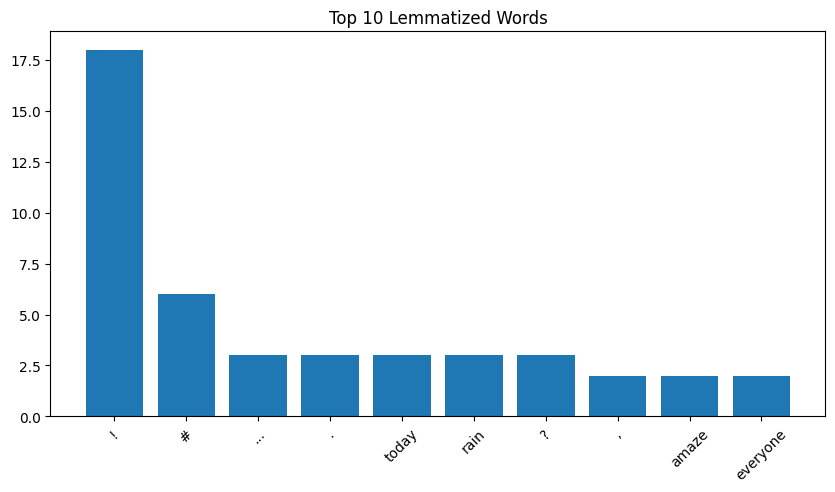

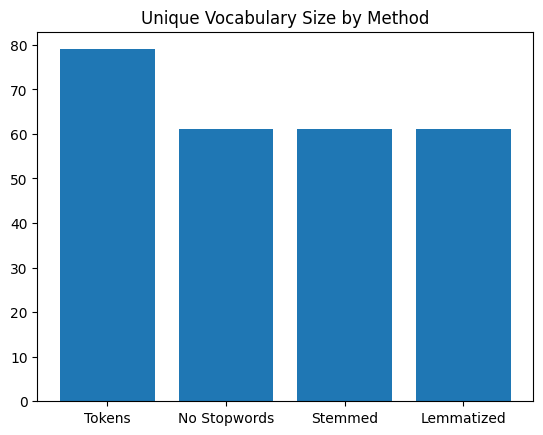

In [11]:
import matplotlib.pyplot as plt
from collections import Counter
import ast

def plot_top_words(tokens_series, title):
    all_tokens = [t for sublist in tokens_series for t in sublist]
    counts = Counter(all_tokens).most_common(10)
    words, freqs = zip(*counts)
    plt.figure(figsize=(10, 5))
    plt.bar(words, freqs)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_top_words(df['pos_lemmatized'], "Top 10 Lemmatized Words")

# Vocabulary comparison
methods = ['Tokens', 'No Stopwords', 'Stemmed', 'Lemmatized']
counts = [
    len(set([t for s in df['word_tokens'] for t in s])),
    len(set([t for s in df['tokens_no_stopwords'] for t in s])),
    len(set([t for s in df['stemmed_tokens'] for t in s])),
    len(set([t for s in df['pos_lemmatized'] for t in s]))
]
plt.bar(methods, counts)
plt.title("Unique Vocabulary Size by Method")
plt.show()

## ✅ Verification & 🛠 Troubleshooting

### Verification Checklist
- [x] `social_media_posts.csv` exists.
- [x] All 10 rows are present.
- [x] Lowercasing and cleaning functions return expected strings.

### Troubleshooting
- **NLTK Resource Error:** If you see `LookupError`, re-run the `nltk.download` cell.
- **ast.literal_eval Issues:** If loading CSV results in strings instead of lists, use `df['col'].apply(ast.literal_eval)`.
- **Strange Lemmatization:** If 'running' doesn't become 'run', ensure you are passing the POS tag to the lemmatizer.

## 📚 Key Takeaways & 🎓 What You Learned
- **Cleaning is essential:** Raw text is too noisy for most models.
- **Tokenization is the foundation:** Everything starts with breaking text into pieces.
- **Normalizing reduces sparsity:** Stemming and lemmatization help the model see that 'running' and 'runs' are the same concept.

## 🌍 Real-World Importance
Text preprocessing is the first step in building search engines, spam filters, and sentiment analysis tools used by companies like Google, Meta, and Netflix.

## 🏁 Conclusion
You have successfully built a full NLP preprocessing pipeline! You are now ready to feed this cleaned data into machine learning models for advanced analysis.